# COMP9414 Assignment 1 — Search and Planning
**zID:** z5726492

**Due:** Friday 3 July 2026, 5:00 PM AEST

## Setup and Imports

In [14]:
import sys
!{sys.executable} -m pip install "ai9414>=0.1.4" matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: /Users/yongjaeshin/.pyenv/versions/3.12.4/bin/python -m pip install --upgrade pip


In [15]:
from __future__ import annotations

import json
import math
import heapq
import matplotlib.pyplot as plt 
from collections import deque
from pathlib import Path
from typing import Any

# Planning helpers (requires: pip install ai9414>=0.1.4)
from ai9414.strips import (
    apply_action_signature,
    get_applicable_actions,
    get_initial_facts,
)

## Helper: Load Data Files

In [16]:
DATA_DIR = Path("data")

def load_graph(name: str) -> dict:
    """
    This is assuming that data for assignments live under ${pwd}/data folder.
    """
    with open(DATA_DIR / "graphs" / name) as f:
        return json.load(f)

def load_planning(name: str) -> dict:
    """Load a planning JSON file from data/planning/."""
    with open(DATA_DIR / "planning" / name) as f:
        return json.load(f)

# Quick test
office = load_graph("office.json")
print(f"Office graph: {len(office['nodes'])} nodes, {len(office['edges'])} edges")
print(f"Start: {office['start']}, Goal: {office['goal']}")

Office graph: 6 nodes, 8 edges
Start: corridor, Goal: lab


---
# Part A: Problem Formulation and Hand Search Traces

## 4.1 Office Graph Formulation

In [17]:
from IPython.display import Image
Image(url="https://i.imgur.com/OeRA9qR.png")

### Q1: State the initial state, goal test, actions, transition model, and path cost for this graph.

- Initial state: `corridor`
- Goal test: `state == lab`
- Actions: Move along any edge to an adjacent room (bidirectional)
- Transition model: Moving from room A to room B changes the current state to B
- Path cost: Sum of edge costs along the path

### Q2: Draw or tabulate the first three frontier updates for DFS, BFS, and UCS.

#### DFS

DFS (stack, LIFO. push in reverse alphabetical so alphabetically first is popped)

| Step | Pop       | Frontier                                                                                       |
|------|-----------|------------------------------------------------------------------------------------------------|
| 0    | -         | [corridor]                                                                                     |
| 1    | corridor  | [mail_room, office_a, office_b]                                                                |
| 2    | mail_room | [storage, office_a, office_b] <- mail_room's unvisited neighbours [visited(corridor), storage] |
| 3    | storage   | [lab, office_a, office_b] <- storage's unvisited neighbours [lab, visited(mail_room)]          |
| 4    | lab       | GOAL_FOUND                                                                                     |


#### BFS

queue, FIFO — push alphabetically, pop from front

| Step | Dequeue   | Visited                                   | Queue                           |
|------|-----------|-------------------------------------------|---------------------------------|
| 0    |           | {corridor}                                | [corridor]                      |
| 1    | corridor  | {corridor, mail_room, office_a, office_b} | [mail_room, office_a, office_b] |
| 2    | mail_room | + { storage }                             | [office_a, office_b, storage]   |
| 3    | office_a  | + { lab }                                 | [office_b, storage, lab]        |
| 4    | office_b  | (no new unvisited)                        | [storage, lab]                  |
| 5    | storage   | (lab already visited)                     | [lab]                           |
| 6    | lab       | GOAL FOUND                                |                                 |



#### UCS

min-heap by cumulative cost

| Step | Pop       | Cost | Heap After                                                                                                                                                                                |
|------|-----------|------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| 0    |           |      | [(0, corridor)]                                                                                                                                                                           |
| 1    | corridor  | 0    | [(2, mail_room), (2, office_a), (3, office_b)]                                                                                                                                            |
| 2    | mail_room | 2    | [(2, office_a), (3, office_b), (4, storage)]                                                                                                                                              |
| 3    | office_a  | 2    | [(3, office_b), (4, storage), (4, office_b via office_a), (10, lab)] - but office_b: new cost 2+2=4 > 3 existing, so no relax. lab: 2+8=10, push [(3, office_b), (4, storage), (10, lab)] |
| 4    | office_b  | 3    | [(4, storage), (6, lab), (10, lab)] ← lab via office_b: 3+3=6 < 10 RELAX                                                                                                                  |
| 5    | storage   | 4    | [(6, lab), (10, lab), (11, lab)] ← lab via storage: 4+7=11 > 6 NO RELAX. 11 > 6 so don't push [(6, lab), (10, lab)]                                                                       |
| 6    | lab       | 6    | GOAL FOUND                                                                                                                                                                                |


### Q3: Report the full expansion order for DFS, BFS, and UCS.

#### DFS

DFS expansion order: corridor, mail_room, storage, lab

#### BFS

BFS expansion order: corridor, mail_room, office_a, office_b, storage, lab

#### UCS

UCS expansion order: corridor, mail_room, office_a, office_b, storage, lab


### Q4: Report the returned path and returned cost for each algorithm.


#### DFS

DFS path: corridor → mail_room → storage → lab

DFS cost: 2 + 2 + 7 = 11

#### BFS


BFS path: corridor → office_a → lab (parent of lab = office_a, parent of office_a = corridor)

BFS cost: 2 + 8 = 10

#### UCS

UCS path: corridor → office_b → lab

UCS cost: 3 + 3 = 6

### Q5: Explain why BFS and UCS can return different paths on this graph.

BFS finds the shallowest path (fewest edges) corridor -> office_a -> lab has only 2 edges - that's the minimum but it costs 2 + 8 = 10
UCS finds the cheapest path (lowest cost) corridor -> office_b -> lab has 2 edges but costs 3 + 3 = 6. UCS discovers this because it expands office_b (costs 3) before office_a's edge (costs 10) gets popped

BFS doesn't care about costs, it picks office_a because it's enqueued before office_b alpahbatically. UCS picks office_b -> lab because 6 < 10

Key insights: BFS is optimal only when all edge costs are same. When costs vary, UCS wins.

## 4.2 Search tree versus state space

State space graph: each room appears exactly once as a node. The office graph has 6 nodes (corridor, mail_room, office_a, office_b, storage, lab) and 8 edges.

Search tree: each node represents a state + the path to reach it. The same room can appear multiple times because there are multiple paths to reach it

---
# Part B: Implement Graph Search

## 5.1 `solve_graph(problem, algorithm)`

In [18]:
def build_adjacency(graph: dict[str, Any]) -> dict[str, list[str]]:
    """
    Build an adjacency list from the graph dictionary.

    The graph uses this format:
        {
            "nodes": [{"id": "A", "x": 0.1, "y": 0.2}, ...],
            "edges": [{"u": "A", "v": "B"}, ...],
            "start": "A",
            "goal": "G"
        }
    """
    adjacency = {str(node["id"]): [] for node in graph["nodes"]}
    for edge in graph["edges"]:
        left = str(edge["u"])
        right = str(edge["v"])
        adjacency[left].append(right)
        adjacency[right].append(left)
    for node_id in adjacency:
        adjacency[node_id].sort()
    return adjacency


def build_adjacency_with_weight(graph: dict[str, Any]) -> dict[str, list[tuple[str, float]]]:
    """
    Build an adjacency list from the weighted graph dictionary.

    The graph uses this format:
        {
            "nodes": [{"id": "A", "x": 0.1, "y": 0.2}, ...],
            "edges": [{"u": "A", "v": "B", "cost": 1.7}, ...],
            "start": "A",
            "goal": "G"
        }
    """
    adjacency = {str(node["id"]): [] for node in graph["nodes"]}
    for edge in graph["edges"]:
        left = str(edge["u"])
        right = str(edge["v"])
        cost = float(edge["cost"])
        adjacency[left].append((right, cost))
        adjacency[right].append((left, cost))
    for node_id in adjacency:
        adjacency[node_id].sort(key=lambda item: (item[1], item[0]))
    return adjacency


def heuristic(graph: dict, node: str, goal: str) -> float:
    """Euclidean distance from node to goal (straight-line heuristic for A*)."""
    positions = {str(n["id"]): (float(n["x"]), float(n["y"])) for n in graph["nodes"]}
    return math.dist(positions[node], positions[goal])


def get_neighbours(adjacency: dict[str, list[tuple[str, float]]], node_id: str) -> list[tuple[str, float]]:
    """
    Return neighbouring nodes in deterministic UCS order.

    Important:
        The order matters. The demo expects a fixed order for a fixed graph.
    """
    return list(adjacency[node_id])


def normalise_node_id(raw: Any) -> str:
    """
    Convert one node id into a Python string.

    Example:
        normalise_node_id("A") returns "A".
    """
    return str(raw)



def reconstruct_path(parents: dict[str, str | None], goal: str) -> list[str]:
    """
    Reconstruct the final path from the start node to the goal node.
    """
    path: list[str] = []
    current: str | None = goal
    while current is not None:
        path.append(current)
        current = parents[current]
    path.reverse()
    return path



def solve_graph(problem: dict, algorithm: str) -> dict:
    """
    Solve a graph search problem using the specified algorithm.
    
    Args:
        problem: Graph dict with nodes, edges, start, goal.
        algorithm: One of 'dfs', 'bfs', 'ucs', 'astar'.
    
    Returns:
        Dict with: status, path, plan, cost, expanded_order,
                   expanded_count, generated_count, frontier_peak.
    """
    start = normalise_node_id(problem["start"])
    goal = normalise_node_id(problem["goal"])
    adjacency = build_adjacency(problem)
    adjacency_with_weights = build_adjacency_with_weight(problem)
    expanded_order = []
    generated_count = 1
    frontier_peak = 1

    if algorithm == "dfs":
        stack = [start]
        visited = {start}
        parents = {start: None}
        

        while stack:
            frontier_peak = max(frontier_peak, len(stack))
            current = stack[-1]
            expanded_order.append(current)
            
            # Goal check: if the top of the stack is the goal, we're done
            if current == goal:
                return {
                  "status": "found",                                                                           
                  "path": reconstruct_path(parents, goal),    
                  "plan": [],
                  "cost": None,
                  "expanded_order": expanded_order,
                  "expanded_count": len(expanded_order),
                  "generated_count": generated_count,                                                          
                  "frontier_peak": frontier_peak,
              }

            # Find the first unvisited neighbour (sorted order for determinism)
            neighbors = adjacency[current]
            next_node = None
            for n in neighbors:
                if n not in visited:
                    next_node = n
                    break
    
            if next_node is not None:
                # EXPAND: push the neighbour and go deeper
                stack.append(next_node)
                visited.add(next_node)
                parents[next_node] = current
                generated_count += 1
            else:
                # BACKTRACK: no unvisited neighbours — dead end, pop and retreat
                stack.pop()
    
    elif algorithm == "bfs":
        queue = deque([start])
        visited = {start}
        parents = {start: None}

        while queue:
            frontier_peak = max(frontier_peak, len(queue))
            node = queue.popleft()  # take the OLDEST node (FIFO = breadth-first)
            expanded_order.append(node)
            
            # Goal check: if the node we just dequeued is the goal, we're done
            if node == goal:
                return {
                    "status": "found",
                    "path": reconstruct_path(parents, goal),
                    "plan": [],                                                                                  
                    "cost": None,
                    "expanded_order": expanded_order,                                                            
                    "expanded_count": len(expanded_order),      
                    "generated_count": generated_count,
                    "frontier_peak": frontier_peak,                                                              
                }
    
            # Expand: enqueue ALL unvisited neighbours (sorted for determinism)
            neighbors = adjacency[node]
            for neighbor in neighbors:
                if neighbor not in visited:
                    visited.add(neighbor)
                    parents[neighbor] = node
                    queue.append(neighbor)
                    generated_count += 1
        
    elif algorithm == "ucs":

        frontier = [(0, start)]
        parents: dict[str, str | None] = {start: None}
        visited = set()
        best_costs: dict[str, float] = {start: 0.0}
    
        while frontier:
            frontier_peak = max(frontier_peak, len(frontier))  
            cost, node = heapq.heappop(frontier)
    
            # Skip stale entries: if we already finalised this node via a cheaper path, this heap entry is outdated — ignore it
            if node in visited:
                continue

            # Finalise this node: once popped, its cost is guaranteed optimal
            visited.add(node)
            expanded_order.append(node)
           
            if node == goal:
                return {
                    "status": "found",
                    "path": reconstruct_path(parents, goal),
                    "plan": [],
                    "cost": cost,
                    "expanded_order": expanded_order,
                    "expanded_count": len(expanded_order),
                    "generated_count": generated_count,
                    "frontier_peak": frontier_peak,
                }

            for neighbor, edge_cost in get_neighbours(adjacency_with_weights, node):
                new_cost = cost + edge_cost
                if neighbor not in best_costs or new_cost < best_costs[neighbor]:
                    best_costs[neighbor] = new_cost
                    parents[neighbor] = node
                    heapq.heappush(frontier, (new_cost, neighbor))
                    generated_count += 1
 
    elif algorithm == "astar":
        counter = 0
        h_start = heuristic(problem, start, goal)
        frontier = [(h_start, [start], counter, start)]
        best_g: dict[str, float] = {start: 0.0}
        visited = set()
        
        while frontier:
            frontier_peak = max(frontier_peak, len(frontier))
            f_val, path, _, node = heapq.heappop(frontier)
            
            if node in visited:
                continue

            visited.add(node)
            expanded_order.append(node)
            
            g_val = best_g[node]
            
            if node == goal:
                return {
                    "status": "found",
                    "path": path,
                    "plan": [],
                    "cost": g_val,
                    "expanded_order": expanded_order,
                    "expanded_count": len(expanded_order),
                    "generated_count": generated_count,
                    "frontier_peak": frontier_peak,
                }
            
            for neighbour, edge_cost in adjacency_with_weights[node]:
                new_g = g_val + edge_cost
                if new_g < best_g.get(neighbour, float("inf")):
                    best_g[neighbour] = new_g
                    counter += 1
                    new_path = path + [neighbour]
                    new_f = new_g + heuristic(problem, neighbour, goal)
                    heapq.heappush(frontier, (new_f, new_path, counter, neighbour))
                    generated_count += 1

    else:
        return {
            "status": "error",
            "path": [], "plan": [], "cost": None,
            "expanded_order": [], "expanded_count": 0,
            "generated_count": 0, "frontier_peak": 0,
            "message": f"Unknown algorithm: {algorithm}",
        }
            
    return {
        "status": "not_found", "path": [], "plan": [], "cost": None,
        "expanded_order": expanded_order, "expanded_count": len(expanded_order),
        "generated_count": generated_count, "frontier_peak": frontier_peak,
    }


### Quick Test: solve_graph on office

In [19]:
office = load_graph("office.json")
for alg in ["dfs", "bfs", "ucs", "astar"]:
      result = solve_graph(office, alg)                                                                
      print(f"{alg:6s} | status={result['status']} | cost={result.get('cost', 'N/A')} | path={result.get('path', [])}")                                                                      
      print(f"       | expanded={result.get('expanded_order', [])} | expanded_count={result.get('expanded_count', 0)}")                                                   
      print(f"       | generated_count={result.get('generated_count', 0)} | frontier_peak={result.get('frontier_peak', 0)}")                                                     
      print() 

dfs    | status=found | cost=None | path=['corridor', 'mail_room', 'storage', 'lab']
       | expanded=['corridor', 'mail_room', 'storage', 'lab'] | expanded_count=4
       | generated_count=4 | frontier_peak=4

bfs    | status=found | cost=None | path=['corridor', 'office_a', 'lab']
       | expanded=['corridor', 'mail_room', 'office_a', 'office_b', 'storage', 'lab'] | expanded_count=6
       | generated_count=6 | frontier_peak=3

ucs    | status=found | cost=6.0 | path=['corridor', 'office_b', 'lab']
       | expanded=['corridor', 'mail_room', 'office_a', 'office_b', 'storage', 'lab'] | expanded_count=6
       | generated_count=7 | frontier_peak=3

astar  | status=found | cost=6.0 | path=['corridor', 'office_b', 'lab']
       | expanded=['corridor', 'office_b', 'office_a', 'mail_room', 'lab'] | expanded_count=5
       | generated_count=6 | frontier_peak=3



## 5.2 Evaluation: Run all four algorithms on all Graphs

In [20]:
graph_files = ["office.json", "graph1.json", "graph2.json", "graph3.json"]
algorithms = ["dfs", "bfs", "ucs", "astar"]
                                                                                                       
all_results = {}
                                                                                                       
print(f"{'Graph':<14} {'Alg':<6} {'Status':<10} {'Cost':<8} {'Expanded':<10} {'Generated':<11} {'Peak':<6} Path")
print("-" * 100)                                                                                     
                                                                  
for gf in graph_files:
  graph = load_graph(gf)
  for alg in algorithms:
      r = solve_graph(graph, alg)                                                                  
      all_results[(gf, alg)] = r
      cost = r.get('cost')                                                                         
      cost_str = f"{cost:.1f}" if cost is not None else "N/A" 
      path_str = " → ".join(r.get('path', [])) if r.get('path') else "—"                           
      print(f"{gf:<14} {alg:<6} {r.get('status','?'):<10} {cost_str:<8} {r.get('expanded_count',0):<10} {r.get('generated_count',0):<11} {r.get('frontier_peak',0):<6} {path_str}")

Graph          Alg    Status     Cost     Expanded   Generated   Peak   Path
----------------------------------------------------------------------------------------------------
office.json    dfs    found      N/A      4          4           4      corridor → mail_room → storage → lab
office.json    bfs    found      N/A      6          6           3      corridor → office_a → lab
office.json    ucs    found      6.0      6          7           3      corridor → office_b → lab
office.json    astar  found      6.0      5          6           3      corridor → office_b → lab
graph1.json    dfs    found      N/A      6          6           6      S → H → A → B → C → G
graph1.json    bfs    found      N/A      16         16          6      S → N → B → C → G
graph1.json    ucs    found      1.0      16         19          7      S → M → D → B → I → G
graph1.json    astar  found      1.0      11         19          9      S → M → D → B → I → G
graph2.json    dfs    found      N/A      6    

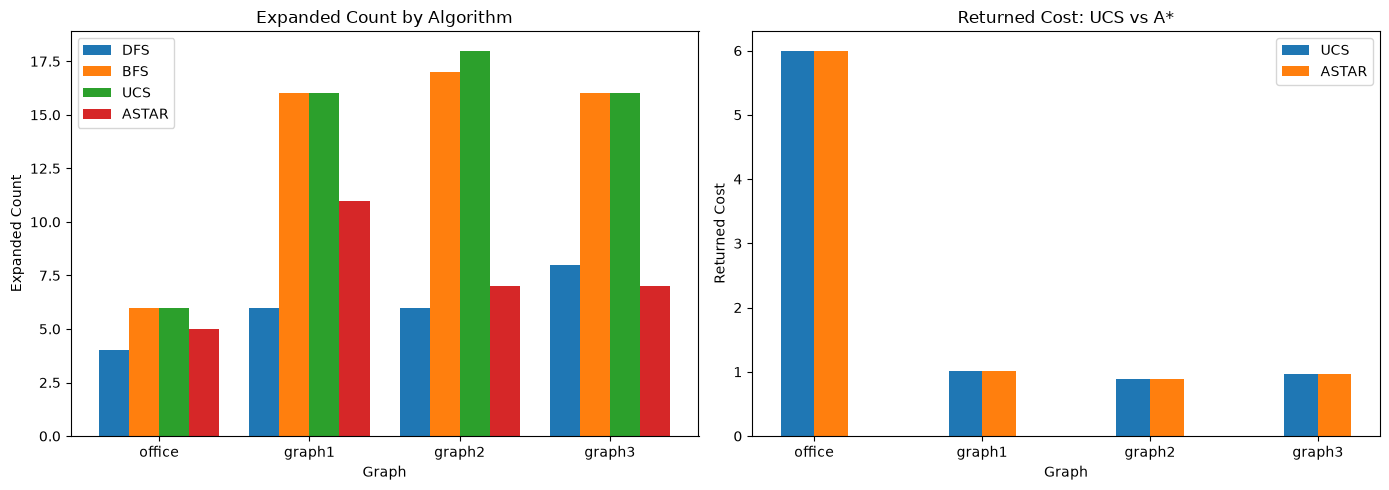

In [21]:
graph_files_plot = ["office.json", "graph1.json", "graph2.json", "graph3.json"]
algorithms_plot = ["dfs", "bfs", "ucs", "astar"]

expanded_data = {alg: [] for alg in algorithms_plot}
cost_data = {alg: [] for alg in algorithms_plot}

for gf in graph_files_plot:
    graph = load_graph(gf)
    for alg in algorithms_plot:
      r = solve_graph(graph, alg)
      expanded_data[alg].append(r['expanded_count'])
      cost_data[alg].append(r['cost'] if r['cost'] is not None else 0)

x = range(len(graph_files_plot))                                                                                 
width = 0.2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i, alg in enumerate(algorithms_plot):                       
  ax1.bar([xi + i * width for xi in x], expanded_data[alg], width, label=alg.upper())
ax1.set_xlabel('Graph')
ax1.set_ylabel('Expanded Count')
ax1.set_title('Expanded Count by Algorithm')
ax1.set_xticks([xi + 1.5 * width for xi in x])
ax1.set_xticklabels([gf.replace('.json', '') for gf in graph_files_plot])
ax1.legend()

for i, alg in enumerate(["ucs", "astar"]):
    ax2.bar([xi + i * width for xi in x], cost_data[alg], width, label=alg.upper())                              
ax2.set_xlabel('Graph')
ax2.set_ylabel('Returned Cost')
ax2.set_title('Returned Cost: UCS vs A*')
ax2.set_xticks([xi + 0.5 * width for xi in x])
ax2.set_xticklabels([gf.replace('.json', '') for gf in graph_files_plot])
ax2.legend()

plt.tight_layout()
plt.savefig('search_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part C: A* Heuristic Behaviour (1.5 marks)

## 6.1 Straight-line Heuristic

The heuristic is Euclidean distance: $h(n) = \sqrt{(x_n - x_g)^2 + (y_n - y_g)^2}$

This is already implemented & used in 5.1 `solve_graph(problem, algorithm)` above

## 6.2 Empirical Comparison: UCS vs A*

In [22]:
comparison_graphs = ["graph1.json", "graph2.json"]

print(f"{'Graph':<14} {'Alg':<6} {'Cost':<8} {'Expanded':<10} {'Generated':<11} {'Peak':<6}")
print("-" * 60)

for gf in comparison_graphs:
    graph = load_graph(gf)
    for alg in ["ucs", "astar"]:
        r = solve_graph(graph, alg)
        cost_str = f"{r['cost']:.3f}" if r['cost'] is not None else "None"
        print(f"{gf:<14} {alg:<6} {cost_str:<8} {r['expanded_count']:<10} {r['generated_count']:<11} {r['frontier_peak']:<6}")
    print()

Graph          Alg    Cost     Expanded   Generated   Peak  
------------------------------------------------------------
graph1.json    ucs    1.009    16         19          7     
graph1.json    astar  1.009    11         19          9     

graph2.json    ucs    0.886    18         18          6     
graph2.json    astar  0.886    7          16          10    



### 3. Identify a point in the trace where A* chooses a different frontier entry from UCS because of h(n).

On graph1.json

UCS expanded order: [S → M → D → B → I → G]

A* expanded order: [S → M → D → B → I → G]

- The first divergence occurs at position 2. After expanding S and M, UCS picks the node with the lowest g(n), while A* picks the node with the lowest f(n) = g(n) + h(n). The heuristic h(n) penalises nodes far from the goal and rewards nodes closer to it, reordering the frontier

### 4. Explain how the heuristic changed the search effort relative to UCS.

- On graph1, A* expanded 11 nodes versus UCS's 16 —
- On graph2, A* expanded 7 versus 18
- The Euclidean heuristic steers A* toward the goal, avoiding expanding nodes that lead away from it
   
### 5. Discuss one limitation of Euclidean distance when edge costs ≠ geometric distance.

- The Euclidean heuristic assumes edge costs correspond to geometric distances. If edge costs include non-distance factors like toll-fee, difficulty then heuristic becomes a loose lower bound
- It is still admissible, so A* still finds optimal paths, but the gap between h(n) and true cost grows large.
- when h(n) is loose, A* gains little pruning over UCS because f(n) = g(n) and heuristic barely influences frontier ordering


---
# Part D: STRIPS Modelling and Forward Planning

## 7.1 Office Delivery Domain

Objects: `robot`, `parcel`, `keycard`, `lab_door`  
Rooms: `corridor`, `mail_room`, `office_a`, `office_b`, `lab`  
Goal: `at(parcel, lab)`

Actions: `move`, `pickup_keycard`, `pickup_parcel`, `unlock_door`, `drop_parcel`

## 7.2 Plan Diagnosis: `lab_via_office_b`

Proposed plan:
1. `move(robot, corridor, mail_room)`
2. `pickup_parcel(robot, parcel, mail_room)`
3. `move(robot, mail_room, corridor)`
4. `move(robot, corridor, office_b)`
5. `move(robot, office_b, lab)`
6. `drop_parcel(robot, parcel, lab)`

### Q1: identify the first action that is not applicable when reached

The first action that fails is `move(robot, office_b, lab)`

Initial states:
- at(robot, corridor), at(parcel, mail_room), at(keycard, office_a)
- handempty(robot), locked(lab_door)                                                                             
- connected(corridor, lab), connected(lab, corridor) (plus other connections)
- door_between(lab_door, corridor, lab)

After action 1 `move(robot, corridor, mail_room)` - works, robot is in the mailroom
After action 2 `pickup_parcel(robot, parcel, mail_room)` - works, robot is carrying the parcel
After action 3 `move(robot, mail_room, corridor)` - works, robot is back to the corridor
After action 4 `move(robot, corridor, office_b)` — works, robot in office_b

Action 5 fails as move required `connected(office_b, lab)` as a precondition but `corridor ↔ lab (the locked edge)`



### Q2: name every missing precondition or false fact that blocks that action

For the move action move(robot, office_b, lab)
- requires connected(office_b, lab) to be true, but this fact does not exist in the state.
- unlocked(lab_door) does not exist - The door is still `locked(lab_door)` because the robot never picked up the keycard from `office_a`

### Q3: explain why simply inserting unlock_door immediately before the blocked action is still not enough

- unlock_door requires `has(robot, keycard)`, the robot never picked up the keycard from office_a. So unlock_door itself is not applicable either.
- There is no connect edge between office_b and lab, so even if door was unlocked `move(robot, office_b, lab)` would still fail because `connected(office_b, lab)` doesn't exist.

### Q4: Valid repaired plan

1. move(robot, corridor, office_a)                                                                               
2. pickup_keycard(robot, keycard, office_a)  
3. move(robot, office_a, corridor)                                                                               
4. move(robot, corridor, mail_room)                                                                              
5. pickup_parcel(robot, parcel, mail_room)                                                                       
6. move(robot, mail_room, corridor)                                                                              
7. unlock_door(robot, keycard, lab_door, corridor, lab)         
8. move(robot, corridor, lab)                                                                                    
9. drop_parcel(robot, parcel, lab)

### Q5: identify where your repaired plan first makes unlocked(lab_door) true;

`unlock_door(robot, keycard, lab_door, corridor, lab)` is where `unlocked(lab_door)` first becomes true. This action's delete effect removes `locked(lab_door)` and its add effect adds `unlocked(lab_door)`, which then allows step 8's `move(robot, corridor, lab)` to succeed.

### Q6: How the final state satisfies at(parcel, lab)

Step 9: `drop_parcel(robot, parcel, lab)` satisfies the goal:                                                    
- Preconditions met: `at(robot, lab)` (from step 8) and `carrying(robot, parcel)` (from step 5)
- Delete effect: removes `carrying(robot, parcel)   `                                                              
- Add effect: adds `at(parcel, lab)` and `handempty(robot)`                                                    


## 7.3 Forward BFS Planner: `solve_planning(problem)`

In [23]:
def state_id(facts):
    """Stable canonical id for a state (sorted tuple of fact tuples)."""
    return tuple(sorted(facts))
    
def goal_satisfied(facts, goal):
    """True when every goal fact is present in the current state."""
    return set(tuple(g) for g in goal).issubset(set(tuple(f) for f in facts))

def solve_planning(problem: dict) -> dict:
    """
    Forward state-space BFS planner using STRIPS.
    
    Args:
        problem: Planning problem dict.
    
    Returns:
        Dict with: status, path, plan, cost, expanded_order,
                   expanded_count, generated_count, frontier_peak.
    """

    start = get_initial_facts(problem)
    goal = problem["goal"]
    
    frontier = deque([(start, [])])  # (facts, plan)
    visited = {state_id(start)}
    expanded_order = []
    generated_count = 1
    frontier_peak = 1
    
    while frontier:
        frontier_peak = max(frontier_peak, len(frontier))
        facts, plan = frontier.popleft()
        
        sid = state_id(facts)
        expanded_order.append(sid)
        
        if goal_satisfied(facts, goal):
            return {
                "status": "found",
                "path": [],
                "plan": plan,
                "cost": len(plan),
                "expanded_order": expanded_order,
                "expanded_count": len(expanded_order),
                "generated_count": generated_count,
                "frontier_peak": frontier_peak,
            }
        
        for action in get_applicable_actions(problem, facts):
            next_facts = apply_action_signature(problem, facts, action)
            next_sid = state_id(next_facts)
            if next_sid not in visited:
                visited.add(next_sid)
                frontier.append((next_facts, plan + [action]))
                generated_count += 1
    
    return {
        "status": "not_found",
        "path": [], "plan": [], "cost": None,
        "expanded_order": expanded_order, "expanded_count": len(expanded_order),
        "generated_count": generated_count, "frontier_peak": frontier_peak,
    }

### Test: solve_planning on canonical_delivery

In [24]:
cd = load_planning("canonical_delivery.json")
result_cd = solve_planning(cd)
print(f"Status: {result_cd['status']}")
print(f"Plan ({result_cd['cost']} actions):")
for i, action in enumerate(result_cd['plan'], 1):
    print(f"  {i}. {action}")
print(f"Expanded: {result_cd['expanded_count']}, Generated: {result_cd['generated_count']}, Frontier peak: {result_cd['frontier_peak']}")

Status: found
Plan (9 actions):
  1. move(robot, corridor, office_a)
  2. pickup_keycard(robot, keycard, office_a)
  3. move(robot, office_a, corridor)
  4. unlock_door(robot, keycard, lab_door, corridor, lab)
  5. move(robot, corridor, mail_room)
  6. pickup_parcel(robot, parcel, mail_room)
  7. move(robot, mail_room, corridor)
  8. move(robot, corridor, lab)
  9. drop_parcel(robot, parcel, lab)
Expanded: 57, Generated: 62, Frontier peak: 14


## 7.4 Planning Comparison

In [25]:
planning_files = ["canonical_delivery.json", "unlocked_lab.json"]

print(f"{'Problem':<25} {'Status':<10} {'Plan Len':<10} {'Expanded':<10} {'Generated':<11} {'Frontier Peak':<6}")
print("-" * 75)

planning_results = {}
for pf in planning_files:
    p = load_planning(pf)
    r = solve_planning(p)
    planning_results[pf] = r
    cost_str = str(r['cost']) if r['cost'] is not None else "None"
    print(f"{pf:<25} {r['status']:<10} {cost_str:<10} {r['expanded_count']:<10} {r['generated_count']:<11} {r['frontier_peak']:<6}")

print("\n--- Final Plans ---")
for pf in planning_files:
    r = planning_results[pf]
    print(f"\n{pf}:")
    for i, action in enumerate(r['plan'], 1):
        print(f"  {i}. {action}")

Problem                   Status     Plan Len   Expanded   Generated   Frontier Peak
---------------------------------------------------------------------------
canonical_delivery.json   found      9          57         62          14    
unlocked_lab.json         found      5          24         29          8     

--- Final Plans ---

canonical_delivery.json:
  1. move(robot, corridor, office_a)
  2. pickup_keycard(robot, keycard, office_a)
  3. move(robot, office_a, corridor)
  4. unlock_door(robot, keycard, lab_door, corridor, lab)
  5. move(robot, corridor, mail_room)
  6. pickup_parcel(robot, parcel, mail_room)
  7. move(robot, mail_room, corridor)
  8. move(robot, corridor, lab)
  9. drop_parcel(robot, parcel, lab)

unlocked_lab.json:
  1. move(robot, corridor, mail_room)
  2. pickup_parcel(robot, parcel, mail_room)
  3. move(robot, mail_room, corridor)
  4. move(robot, corridor, lab)
  5. drop_parcel(robot, parcel, lab)


### Why the unlocked case needs fewer actions

In canonical_delivery, the door is locked, so the robot must:                                                    
1. Go to office_a to pick up the keycard                                                                         
2. Return to corridor                                                                                            
3. Unlock the door   
4. Then go get the parcel and deliver it                                                                         
                                                                  
In unlocked_lab, the door is already unlocked, so the robot skips all the keycard steps. It just picks up the parcel, walks to the corridor, goes straight through to lab, and drops it. Fewer actions because there's no keycard detour and no unlock step.

---
# 9.1 Reusable Evaluation Cell


In [26]:
DATA_DIR = Path("data")

# --- Graph search ---
graph_files = {
    "office": "graphs/office.json",
    "graph1": "graphs/graph1.json",
    "graph2": "graphs/graph2.json",
    "graph3": "graphs/graph3.json",
}
algorithms = ["dfs", "bfs", "ucs", "astar"]

results = {"graph_search": {}, "planning": {}}

print("=" * 100)
print("GRAPH SEARCH RESULTS")
print("=" * 100)
print(f"{'Graph':<10} {'Alg':<6} {'Status':<10} {'Cost':<10} {'Expanded':<10} {'Generated':<11} {'Peak':<6} Path")
print("-" * 100)

for name, filepath in graph_files.items():
    with open(DATA_DIR / filepath) as f:
        graph = json.load(f)
    results["graph_search"][name] = {}
    for alg in algorithms:
        r = solve_graph(graph, alg)
        results["graph_search"][name][alg] = r
        cost_str = f"{r['cost']:.3f}" if r['cost'] is not None else "None"
        path_str = " → ".join(r['path'][:6])
        if len(r['path']) > 6:
            path_str += " → ..."
        print(f"{name:<10} {alg:<6} {r['status']:<10} {cost_str:<10} {r['expanded_count']:<10} {r['generated_count']:<11} {r['frontier_peak']:<6} {path_str}")

# --- Planning ---
planning_files = {
    "canonical_delivery": "planning/canonical_delivery.json",
    "unlocked_lab": "planning/unlocked_lab.json",
}

print("\n" + "=" * 100)
print("PLANNING RESULTS")
print("=" * 100)
print(f"{'Problem':<25} {'Status':<10} {'Plan Len':<10} {'Expanded':<10} {'Generated':<11} {'Peak':<6}")
print("-" * 75)

for name, filepath in planning_files.items():
    with open(DATA_DIR / filepath) as f:
        problem = json.load(f)
    r = solve_planning(problem)
    # Convert expanded_order tuples to strings for JSON serialization
    r_json = dict(r)
    r_json["expanded_order"] = [str(s) for s in r["expanded_order"]]
    results["planning"][name] = r_json
    cost_str = str(r['cost']) if r['cost'] is not None else "None"
    print(f"{name:<25} {r['status']:<10} {cost_str:<10} {r['expanded_count']:<10} {r['generated_count']:<11} {r['frontier_peak']:<6}")
    print(f"  Plan: {r['plan']}")

output_path = "z5726492_results.json"
with open(output_path, "w") as f:
    json.dump(results, f, indent=2, default=str)
print(f"\nResults written to {output_path}")

GRAPH SEARCH RESULTS
Graph      Alg    Status     Cost       Expanded   Generated   Peak   Path
----------------------------------------------------------------------------------------------------
office     dfs    found      None       4          4           4      corridor → mail_room → storage → lab
office     bfs    found      None       6          6           3      corridor → office_a → lab
office     ucs    found      6.000      6          7           3      corridor → office_b → lab
office     astar  found      6.000      5          6           3      corridor → office_b → lab
graph1     dfs    found      None       6          6           6      S → H → A → B → C → G
graph1     bfs    found      None       16         16          6      S → N → B → C → G
graph1     ucs    found      1.009      16         19          7      S → M → D → B → I → G
graph1     astar  found      1.009      11         19          9      S → M → D → B → I → G
graph2     dfs    found      None       6   